<a href="https://colab.research.google.com/github/Ravjot-anand/Python-Notes/blob/main/ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd


In [4]:
df = pd.read_csv('/content/placement.csv')

In [31]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df.shape

(100, 4)

In [7]:
#removing the row unanmed
df = df.iloc[:,1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
import matplotlib.pyplot as plt

<Axes: xlabel='cgpa', ylabel='iq'>

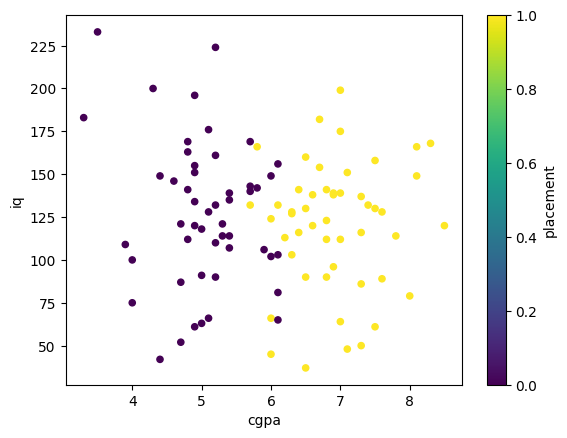

In [10]:
from matplotlib import color_sequences
df.plot.scatter(x='cgpa',y='iq',c='placement',colormap='viridis')


We are using logistic regression algo for the model,
in which the algo draws a line in placement met or not met as you can see in graph

In [11]:
# now we will seprate input and output columns
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
x
#2d tensor

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y
#1d tensor vector

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.1)
#test size 0.1 is just like taking 10 % of value for test

In [16]:
X_train

,cgpa,iq
37,8.1,149.0
71,6.1,132.0
16,5.2,224.0
39,4.6,146.0
81,5.4,107.0
...,...,...
88,4.4,149.0
1,5.9,106.0
42,7.6,89.0
34,4.8,163.0


In [17]:
y_train

,placement
37,1
71,1
16,0
39,0
81,0
...,...
88,0
1,0
42,1
34,0


In [18]:
from sklearn.preprocessing import StandardScaler
#scaling

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)#not use fir as the partern is decided in training

In [20]:
X_train_scaled

array([[ 1.87671427,  0.61836036],
       [ 0.05760512,  0.1754337 ],
       [-0.76099399,  2.57244858],
       [-1.30672674,  0.54019683],
       [-0.57908308, -0.47592904],
       [ 0.87620424,  1.29577761],
       [-1.57959311,  1.94714035],
       [ 0.60333787,  1.47815918],
       [-0.76099399,  0.93101447],
       [ 0.05760512, -0.58014708],
       [ 1.33098153,  0.85285095],
       [ 1.14907061, -1.02307374],
       [ 0.42142695,  0.12332468],
       [-0.94290491, -1.62232746],
       [-0.30621671,  0.4620333 ],
       [ 0.23951604,  0.04516115],
       [-0.30621671,  0.38386977],
       [ 0.42142695,  0.90495997],
       [-1.85245948, -0.65831061],
       [ 0.78524878,  0.33176076],
       [ 1.42193698,  0.07121566],
       [ 1.14907061, -1.96103609],
       [ 1.6038479 , -0.29354747],
       [ 1.14907061, -0.24143846],
       [ 0.23951604, -0.58014708],
       [ 0.87620424,  0.35781526],
       [-1.94341494, -0.42382002],
       [-1.03386037,  1.84292231],
       [-0.76099399,

In [21]:
X_test_scaled

array([[-2.48914769,  1.50421369],
       [-0.85194945,  0.07121566],
       [ 0.05760512, -1.57021844],
       [ 0.87620424, -0.34565649],
       [-1.03386037, -1.67443648],
       [-1.21577128, -1.90892707],
       [ 0.51238241,  0.33176076],
       [-1.48863765, -2.16947216],
       [ 2.05862519,  1.11339604],
       [-0.57908308,  0.25359723]])

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
clf = LogisticRegression()

In [24]:
clf.fit(X_train_scaled, y_train)

LogisticRegression()

In [27]:
y_pred = clf.predict(X_test_scaled)

In [26]:
y_test

,placement
17,0
86,0
56,0
29,1
73,0
94,0
48,1
96,0
53,1
49,0


In [28]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9

In [30]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

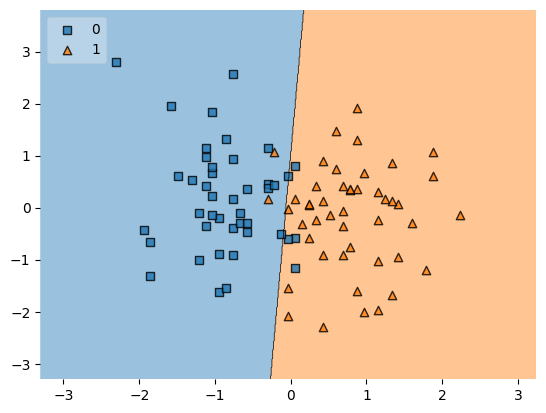

In [32]:
plot_decision_regions(X_train_scaled, y_train.values, clf=clf, legend=2)

In [33]:
#extracting the trained model
import pickle
pickle.dump(clf,open('model.pkl','wb'))